# surrogateAdj

This notebook visualizes only the `rate_x` inferred adjacency runs and builds a surrogate shared-edge mask from the 3-run intersection at binary threshold 0.6.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white', context='talk')

def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'runs_msg_ablation_tau0.99').exists():
        return cwd
    if (cwd / 'Hungarianchickenpox' / 'runs_msg_ablation_tau0.99').exists():
        return cwd / 'Hungarianchickenpox'
    raise FileNotFoundError('Could not locate Hungarianchickenpox/runs_msg_ablation_tau0.99 from the current working directory.')

BASE_DIR = resolve_base_dir()
SIM_RUNS_DIR = BASE_DIR / 'runs_msg_ablation_tau0.99'
GEO_ADJ_PATH = BASE_DIR / 'hungary_chickenpox_adj.npy'
OUTPUT_NPZ_PATH = BASE_DIR / 'surrogateAdj_shared_edge_masks_runs3_thr0p6.npz'

MSG_CONFIG = 'rate_x'
SEEDS = [1, 2, 3]
THRESHOLD = 0.6

county_names = [
    'BACS', 'BARANYA', 'BEKES', 'BORSOD', 'BUDAPEST', 'CSONGRAD', 'FEJER', 'GYOR',
    'HAJDU', 'HEVES', 'JASZ', 'KOMAROM', 'NOGRAD', 'PEST', 'SOMOGY', 'SZABOLCS',
    'TOLNA', 'VAS', 'VESZPREM', 'ZALA',
]

def adj_path(seed: int) -> Path:
    return SIM_RUNS_DIR / f'run{seed}_{MSG_CONFIG}_lam0.001_nozscore_gaussian_tau0.99' / 'best_inferred_adjacency.npy'

adj_data = {seed: np.load(adj_path(seed)) for seed in SEEDS}
geo_adj = np.load(GEO_ADJ_PATH)

print('BASE_DIR =', BASE_DIR)
print('SIM_RUNS_DIR =', SIM_RUNS_DIR)
print('OUTPUT_NPZ_PATH =', OUTPUT_NPZ_PATH)
for seed in SEEDS:
    print(f'run{seed}:', adj_path(seed), adj_data[seed].shape)


BASE_DIR = /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox
SIM_RUNS_DIR = /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/runs_msg_ablation_tau0.99
OUTPUT_NPZ_PATH = /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/surrogateAdj_shared_edge_masks_runs3_thr0p6.npz
run1: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/runs_msg_ablation_tau0.99/run1_rate_x_lam0.001_nozscore_gaussian_tau0.99/best_inferred_adjacency.npy (20, 20)
run2: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/runs_msg_ablation_tau0.99/run2_rate_x_lam0.001_nozscore_gaussian_tau0.99/best_inferred_adjacency.npy (20, 20)
run3: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/runs_msg_ablation_tau0.99/run3_rate_x_lam0.001_nozscore_gaussian_tau0.99/best_inferred_adjacency.npy (20, 20)


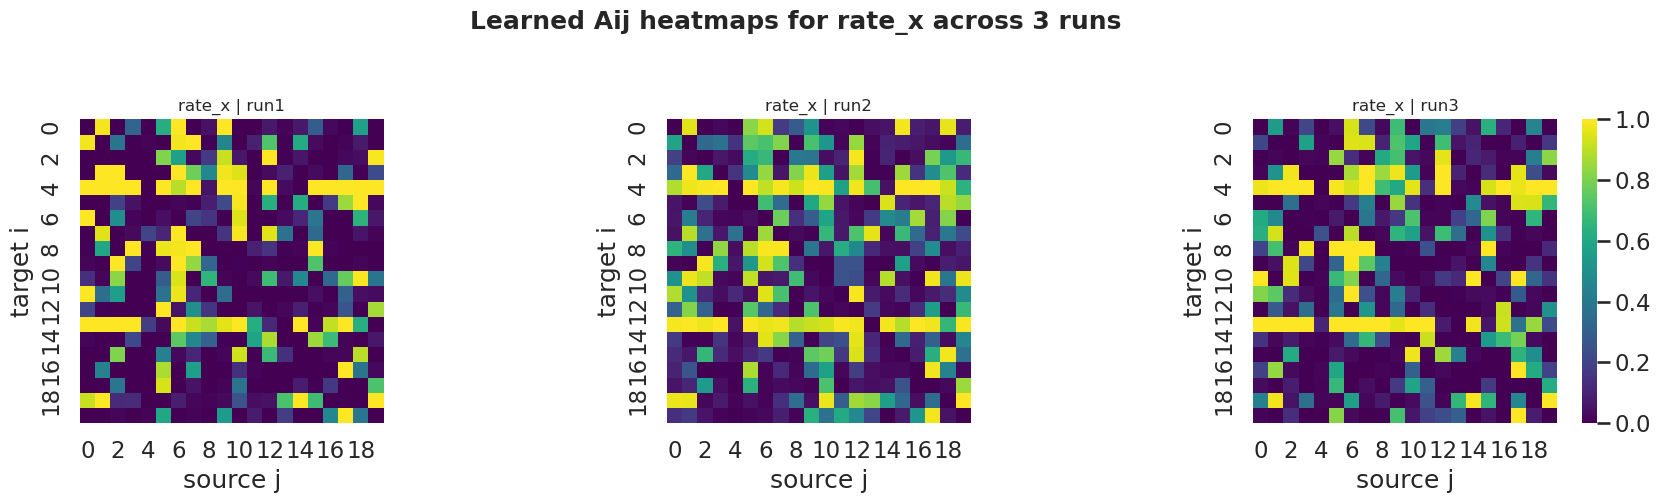

In [2]:
fig, axes = plt.subplots(1, len(SEEDS), figsize=(18, 5))

for ax, seed in zip(axes, SEEDS):
    sns.heatmap(
        adj_data[seed],
        cmap='viridis',
        vmin=0,
        vmax=1,
        square=True,
        cbar=(seed == SEEDS[-1]),
        ax=ax,
    )
    ax.set_title(f'{MSG_CONFIG} | run{seed}', fontsize=12)
    ax.set_xlabel('source j')
    ax.set_ylabel('target i')

plt.suptitle('Learned Aij heatmaps for rate_x across 3 runs', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


In [3]:
mats = np.stack([adj_data[seed] for seed in SEEDS], axis=0)
mean_adj = mats.mean(axis=0)
std_adj = mats.std(axis=0)
shared_mask = np.logical_and.reduce([(adj_data[seed] > THRESHOLD) for seed in SEEDS]).astype(np.uint8)
np.fill_diagonal(shared_mask, 0)

shared_edge_rows = []
n = shared_mask.shape[0]
for i in range(n):
    for j in range(n):
        if i != j and shared_mask[i, j] == 1:
            shared_edge_rows.append({'target_i': county_names[i], 'source_j': county_names[j]})

shared_edge_df = pd.DataFrame(shared_edge_rows)
shared_edge_count = int(shared_mask.sum())
shared_edge_density = float(shared_edge_count / (n * (n - 1)))

summary_df = pd.DataFrame([{
    'msg_config': MSG_CONFIG,
    'num_runs': len(SEEDS),
    'threshold': THRESHOLD,
    'shared_edge_count': shared_edge_count,
    'shared_edge_density': shared_edge_density,
}])

display(summary_df)
display(shared_edge_df)


,msg_config,num_runs,threshold,shared_edge_count,shared_edge_density
0,rate_x,3,0.6,63,0.165789


,target_i,source_j
0,BACS,FEJER
1,BARANYA,FEJER
2,BARANYA,GYOR
3,BARANYA,NOGRAD
4,BEKES,CSONGRAD
...,...,...
58,VAS,ZALA
59,VESZPREM,BARANYA
60,VESZPREM,PEST
61,VESZPREM,ZALA


In [4]:
np.savez_compressed(
    OUTPUT_NPZ_PATH,
    mask_rate_x=shared_mask.astype(np.uint8),
    msg_config=np.array([MSG_CONFIG], dtype=object),
    county_names=np.array(county_names, dtype=object),
    seeds=np.array(SEEDS, dtype=int),
    threshold=np.array([THRESHOLD], dtype=float),
    num_runs=np.array([len(SEEDS)], dtype=int),
)

print(f'saved surrogate shared-edge mask to: {OUTPUT_NPZ_PATH}')


saved surrogate shared-edge mask to: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/surrogateAdj_shared_edge_masks_runs3_thr0p6.npz


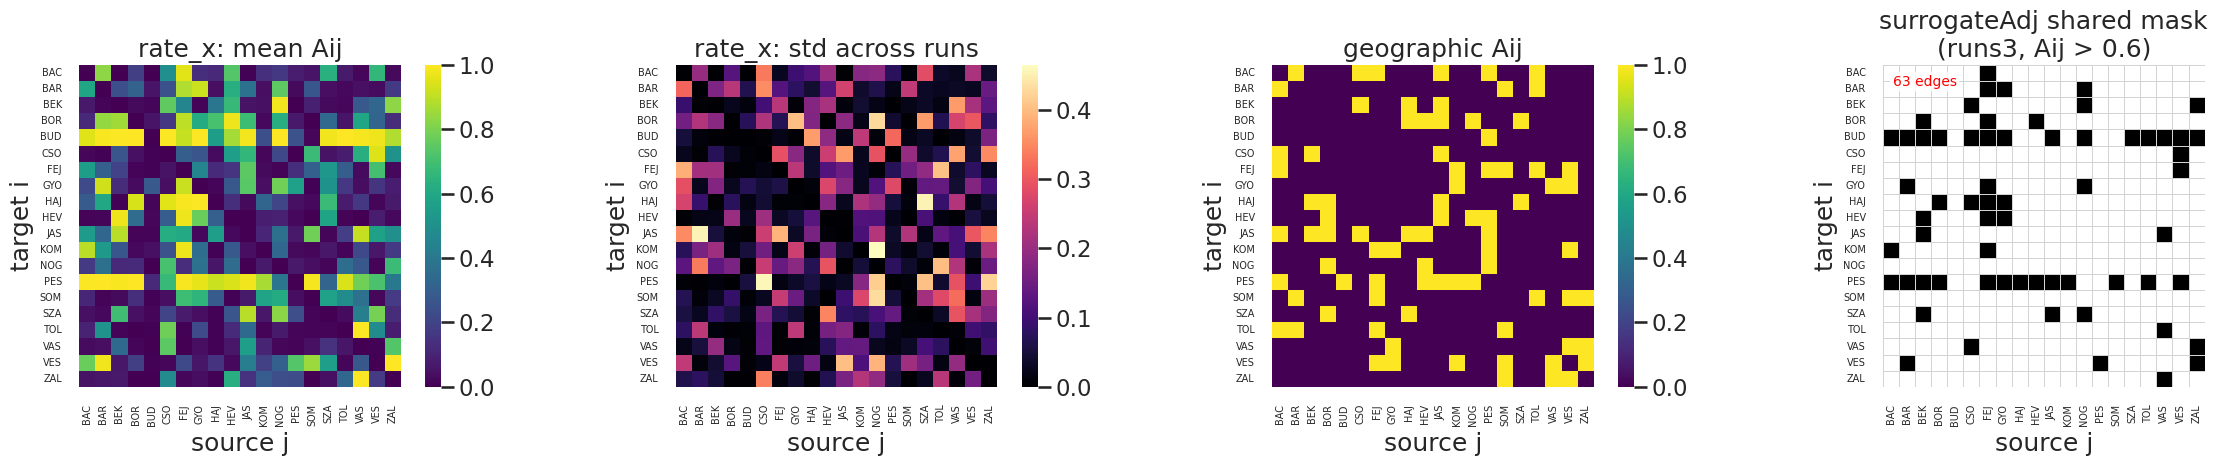

In [5]:
tick_labels = [name[:3].upper() for name in county_names]
N_nodes = len(county_names)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

sns.heatmap(mean_adj, cmap='viridis', vmin=0, vmax=1, square=True, cbar=True, ax=axes[0])
axes[0].set_title(f'{MSG_CONFIG}: mean Aij')

sns.heatmap(std_adj, cmap='magma', vmin=0, square=True, cbar=True, ax=axes[1])
axes[1].set_title(f'{MSG_CONFIG}: std across runs')

sns.heatmap(geo_adj, cmap='viridis', vmin=0, vmax=1, square=True, cbar=True, ax=axes[2])
axes[2].set_title('geographic Aij')

sns.heatmap(
    shared_mask,
    cmap='Greys',
    vmin=0,
    vmax=1,
    square=True,
    cbar=False,
    linewidths=0.5,
    linecolor='lightgrey',
    ax=axes[3],
)
axes[3].set_title(f'surrogateAdj shared mask\n(runs3, Aij > {THRESHOLD})')
axes[3].text(
    0.03, 0.97, f'{shared_edge_count} edges',
    transform=axes[3].transAxes, color='red', fontsize=10, ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none')
)

for ax in axes:
    ax.set_xticks(np.arange(N_nodes) + 0.5)
    ax.set_yticks(np.arange(N_nodes) + 0.5)
    ax.set_xticklabels(tick_labels, fontsize=7, rotation=90)
    ax.set_yticklabels(tick_labels, fontsize=7, rotation=0)
    ax.set_xlabel('source j')
    ax.set_ylabel('target i')

plt.tight_layout()
plt.show()
